Чтобы соединить две таблицы между собой, достаточно записать названия таблиц через запятую в разделе from.
```sql
SELECT * /*выбор всех полей*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
```

Каждая запись, которая есть в таблице ```teams```, будет соединена с каждой записью в таблице ```matches```.

Это действие также называют **декартовым произведением таблиц**.

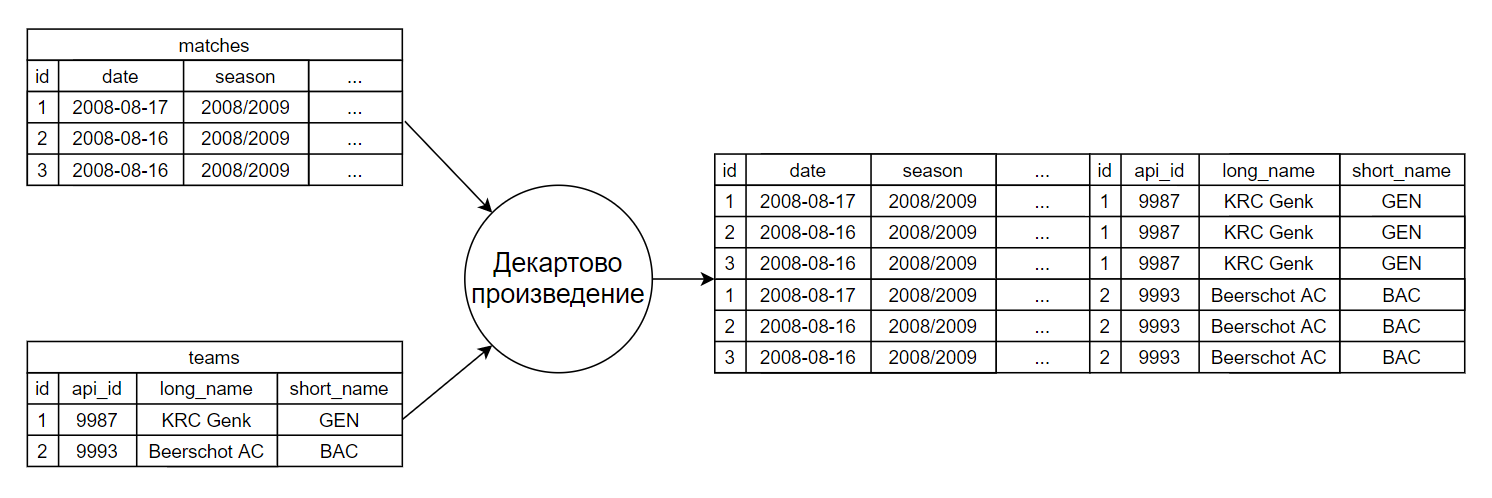

В данном случае соединение таблиц не даёт практической пользы: мы получили очень много записей, которые никак не можем интерпретировать, потому что команды не соответствуют матчам.

Давайте исправим это. В таблице teams есть столбец ```api_id```, а таблица matches содержит столбцы ```home_team_api_id``` и ```away_team_api_id``` — это ключи таблиц, по которым они соединяются.

>Ключ — это поле (столбец) в таблице, которое позволяет однозначно идентифицировать запись (строку).

Чтобы соединить таблицы и получить данные о домашней команде по каждому матчу, добавим условие

```where home_team_api_id = api_id```.

```sql
SELECT * /*выбор всех полей в таблице*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
WHERE home_team_api_id = api_id /*условие: home_team_api_id таблицы matches равен api_id таблицы teams*/

Аналогично можем получить данные о гостевых командах: необходимо изменить условие на

```where away_team_api_id = api_id```.

```sql
SELECT * /*выбор всех полей в таблицы*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
WHERE away_team_api_id = api_id /*условие: away_team_api_id таблицы matches равен api_id таблицы teams*/
```

Ключи бывают двух основных типов:
* **Primary** — первичный ключ — служит для идентификации текущей таблицы и, как правило, идёт первым в списке столбцов. Всегда уникален: повторяющихся значений в основной таблице быть не может.
* **Foreign** — внешний ключ — представляет собой ссылку на другую таблицу.

>С помощью известного нам запроса получим названия команд, игравших домашние матчи, и счёт матчей.
```sql
SELECT 
    long_name, /*столбец long_name таблицы teams*/
    home_team_goals, /*столбец home_team_goals таблицы matches*/
    away_team_goals /*столбец away_team_goals таблицы matches*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
WHERE home_team_api_id = api_id /*условие: home_team_api_id таблицы matches равен api_id таблицы teams*/

>Напишите запрос, который выведет таблицу с результатами матчей для гостевых команд, содержащую:

* названия гостевых команд (long_name),
* количество забитых мячей домашней команды (home_team_goals),
* количество забитых мячей гостевой команды (away_team_goals).

```sql
SELECT 
    long_name, /*столбец long_name таблицы teams*/
    home_team_goals, /*столбец home_team_goals таблицы matches*/
    away_team_goals /*столбец away_team_goals таблицы matches*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
WHERE away_team_api_id = api_id

# <center> JOIN

```sql
SELECT 
    long_name,  /*столбец long_name таблицы teams*/
    home_team_goals, /*столбец home_team_goals таблицы matches*/
    away_team_goals /*столбец away_team_goals таблицы matches*/
FROM
    sql.teams, /*таблица с командами*/
    sql.matches /*таблица с матчами*/
WHERE home_team_api_id = api_id /*условие: home_team_api_id таблицы matches равен api_id таблицы teams*/

>запишем его с использованием JOIN
```sql
SELECT 
    long_name, /*столбец long_name таблицы teams*/
    home_team_goals, /*столбец home_team_goals таблицы matches*/
    away_team_goals /*столбец away_team_goals таблицы matches*/
FROM    
    sql.teams /*таблица с командами*/
JOIN sql.matches on home_team_api_id = api_id /*оператор соединения таблиц; таблица matches; условие: home_team_api_id таблицы matches равен api_id таблицы teams*/

**Его синтаксис можно представить следующим образом:**
```sql
SELECT
        столбец1,
	столбец2,
	...
FROM
	таблица1
JOIN таблица2 ON условие

>С помощью JOIN можно соединить и более двух таблиц.
```sql
SELECT
        столбец1,
	столбец2,
	...
FROM
	таблица1
JOIN таблица2 ON условие
JOIN таблица3 ON условие

В таблицах, которые мы соединяем, могут быть одинаковые названия столбцов.

→ К примеру, столбец id есть и в таблице matches, и в таблице teams. Такой запрос не будет обработан.

Что же делать в таком случае?

Можно указать, откуда мы хотим запросить данные, записав название таблицы перед столбцом через точку.
```sql
SELECT
    teams.id
FROM 
    sql.teams
JOIN sql.matches ON home_team_api_id = api_id

>Можно также выбрать и столбец из таблицы matches.
```sql
SELECT
    matches.id
FROM 
    sql.teams
JOIN sql.matches on home_team_api_id = api_id

Зачастую названия таблиц слишком длинные, так что использовать их неудобно.

>Упростить обращение к различным таблицам можно, присвоив им сокращённые названия — алиасы (от англ. alias).

Синтаксис для указания алиаса такой же, как и для названия столбца.

```sql
SELECT
        столбец1,
	столбец2,
	...
FROM
	таблица1 AS короткое_название_1
JOIN таблица2 AS короткое_название_2 ON условие

Название записывается без пробелов и операторов.

Если необходимо записать название на русском языке ("таблица1") или с пробелом ("table 2"), то алиас можно обернуть в кавычки.

Важно! Обращаться по такому алиасу придётся также с помощью кавычек.
```sql
SELECT
	"таблица1".столбец1,
	"table 2".столбец2,
	...
FROM
	таблица1 AS "таблица1"
	JOIN таблица2 AS "table 2" ON условие

>Ключевое слово as, как и в названии столбца, можно опустить в большинстве СУБД.

```sql
SELECT
        столбец1 новое_название_столбца,
	столбец2 новое_название_столбца,
	...
FROM
	таблица1 короткое_название_1
JOIN таблица2 короткое_название_2 ON условие

>Напишите запрос, который выведет два столбца: id матча (match_id) и id домашней команды (team_id). Отсортируйте по id матча в порядке возрастания значений.
```sql
SELECT
    sql.matches.id AS match_id,
    sql.teams.id AS team_id
FROM
    sql.matches
JOIN sql.teams ON home_team_api_id = api_id
ORDER BY match_id

Давайте с помощью запроса SQL получим таблицу, содержащую:
- название домашней команды;
- количество забитых домашней командой голов;
- количество забитых гостевой командой голов;
- название гостевой команды.

```sql
SELECT
    h.long_name "домашняя команда",
    m.home_team_goals "голы домашней команды",
    m.away_team_goals "голы гостевой команды",
    a.long_name "гостевая команда" 
FROM
    sql.matches m
    JOIN sql.teams h ON m.home_team_api_id = h.api_id
    JOIN sql.teams a ON m.away_team_api_id = a.api_id

>Напишите запрос, который выведет столбцы:
- id матча,
- короткое название домашней команды (home_short),
- короткое название гостевой команды (away_short).
- Отсортируйте запрос по возрастанию id матча.
```sql
SELECT
    m.id,
    h.short_name home_short,
    a.short_name away_short
FROM
    sql.matches m
    JOIN sql.teams h ON m.home_team_api_id = h.api_id
    JOIN sql.teams a ON m.away_team_api_id = a.api_id 
ORDER BY m.id

## <center> Работа с объединёнными таблицами

Принцип построения запроса и порядок операторов такой же, как и с обычной таблицей.

Вспомним его:
```sql
SELECT... 
FROM... 
WHERE... 
GROUP BY... 
ORDER BY... 
LIMIT...

### <center> Фильтрация данных

>Например, можно вывести id матчей, в которых команда Arsenal была гостевой.
```sql
SELECT 
    m.id
FROM
    sql.teams t
    JOIN sql.matches m ON m.away_team_api_id = t.api_id
WHERE long_name = 'Arsenal'

>Напишите запрос, который выведет полное название домашней команды (long_name), количество голов домашней команды (home_goal) и количество голов гостевой команды (away_goal) в матчах, где домашней командой были команды с коротким названием 'GEN'. Отсортируйте запрос по id матча в порядке возрастания.

```sql
select
    t.long_name long_name,
    sum(m.home_team_goals) home_goal,
    sum(m.away_team_goals) away_goal

from
    sql.teams t
    join sql.matches m on m.home_team_api_id = t.api_id

where t.short_name = 'GEN'
GROUP by long_name, m.id
order by m.id

Также мы можем отфильтровать записи сразу по двум таблицам.

>Например, можно оставить только записи, в которых короткое название домашней команды GEN и матчи сезона 2008/2009.

```sql
SELECT *
FROM    
    sql.matches m
    JOIN sql.teams t on t.api_id = m.home_team_api_id
WHERE
    t.short_name = 'GEN'
    AND m.season = '2008/2009'

>Напишите запрос, чтобы вывести id матчей, короткое название домашней команды (home_short), короткое название гостевой команды (away_short) для матчей сезона 2011/2012, в которых участвовала команда с названием Liverpool. Отсортируйте по id матча в порядке возрастания.
```sql
SELECT
    m.id,
    t.short_name home_short,
    t_a.short_name away_short
FROM sql.matches m
JOIN sql.teams t on t.api_id = m.home_team_api_id
JOIN sql.teams t_a on t_a.api_id = m.away_team_api_id
WHERE m.season = '2011/2012' and (t.long_name = 'Liverpool' or t_a.long_name = 'Liverpool')
ORDER BY m.id

### <center> Агрегация данных

>Например, мы можем вывести сумму голов матча, забитых командами, агрегированную по гостевым командам (совокупное количество голов в матче, забитых обеими командами, суммированное в разрезе гостевых команд).

```sql
SELECT
    t.long_name, /*столбец long_name таблицы t*/
    SUM(m.home_team_goals) + SUM(m.away_team_goals) match_goals /*функция суммирования; столбец home_team_goals таблицы m; функция суммирования; столбец away_team_goals таблицы m; новое название столбца*/
FROM
    sql.matches m /*таблица matches с алиасом m*/
    JOIN sql.teams t ON m.away_team_api_id = t.api_id /*оператор соединения таблиц; таблица teams с алиасом t; условие: away_team_api_id таблицы m равен api_id таблицы t*/
GROUP BY t.id /*группировка по столбцу id таблицы t*/

Мы можем использовать оператор HAVING для фильтрации сгруппированных данных.

>Поставим задачу — вывести таблицу с суммарным количеством забитых голов в матчах по командам и сезонам для команд, в которых суммарное количество голов в матчах сезона больше 100.

Для начала посчитаем общее количество голов в матчах по сезонам.
```sql
SELECT
    m.season,
    SUM(m.home_team_goals) + SUM(m.away_team_goals) total_goals
FROM sql.matches m
GROUP BY m.season



>Затем добавим таблицу с командами, группировку по командам и условие фильтрации.
```sql
SELECT
    m.season, /*столбец season таблицы m*/
    t.long_name, /*столбец long_name таблицы t*/
    SUM(m.home_team_goals) + SUM(m.away_team_goals) total_goals /*функция суммирования; столбец home_team_goals таблицы m; функция суммирования; столбец away_team_goals таблицы m; новое название столбца*/
FROM sql.matches m /*таблица matches с алиасом m*/
JOIN sql.teams t ON t.api_id = m.home_team_api_id OR t.api_id = m.away_team_api_id /*оператор соединения таблиц; таблица teams с алиасом t; условие: home_team_api_id таблицы m равен api_id таблицы t или away_team_api_id таблицы m равен api_id таблицы t*/
GROUP BY m.season, t.id /*группировка по столбцам season таблицы m и id таблицы t*/
HAVING SUM(m.home_team_goals) + SUM(m.away_team_goals) > 100 /*оператор фильтрации сгруппированных данных; функция суммирования; home_team_goals таблицы m; функция суммирования; away_team_goals таблицы m; больше 100*/

>Напишите запрос, с помощью которого можно вывести список полных названий команд, сыгравших в гостях 150 и более матчей. Отсортируйте список по названию команды.
```sql
select
t.long_name
from
    sql.matches m
join sql.teams t on t.api_id = m.away_team_api_id
group by t.id
having count(m.id) >= 150
order by t.long_name